In [ ]:
# -*- coding: utf-8 -*-
import numpy as np

from pathlib import Path

from carm import (
    BoreholeGeometry,
    BoreholeMesh,
    BoreholeThermalProperties,
    SingleUtube,
)
from carm import GroundGeometry, GroundMesh
from carm import PhysicalModel
from carm import Simulation
from carm import Fluid
from carm import EnvironmentalProperties, EnvironmentalTimeSeries
from carm import FieldInput

# field
field_path = Path("spacing.xlsx")
path = Path("input_env.xlsx")
n_bhes = 9
x_min = -2.5
y_min = -2.5
x_max = 12.5
y_max = 12.5

# ground properties
stratification = [(1.8, 947.37, 1900, 111)]
n_mesh = 20
m_mesh = 40
D0 = 0.15
rn = 10
Tg = 13
f = 1.2
L = 100  # 12 #m lunghezza peforazione
m_mesh_sup = 4
m_mesh_inf = 40
L_sup = 1
L_inf = 10


# fluid properties
k_w = 0.568709114496803
rho_w = 1000.1435933169
cp_w = 4207.40834247225
ni_w = 1.49626063208248e-6

# borehole properties
# single e double u tube
Dpi = 0.026
Lbore = 100
Rp0 = 0.25
RppB = 0.72
n_pipes = 2
pipe_thick = 0.003
pipe_spacing = 0.0823
cp_0 = 1460
rho_0 = 1655
D0 = 0.15
conf = 1
k0 = 1.8

# external environment properties
absorptance = 0.7
eps = 0.95
At = 10
tau = 0
tau_y = 365 * 24 * 3600
tau_shift = 210 * 24 * 3600
R_ext = 0.04

# external environment input data
T_ext = np.full(276, 5)
SolarRad = np.full(276, 150)
Tm = 13

# simulation
dt = 3600
n_steps = 276

# mw_tot and Tf1
groups = {
    "group_0": [0, 1, 2],
    "group_1": [3, 4, 5],
    "group_2": [6, 7, 8],
}

n_groups = len(groups)

Tf1 = np.full((n_groups, n_steps), 2, dtype=np.float64)
mw_tot = np.full((n_groups, n_steps), 0.1657, dtype=np.float64)

# -----field-----
myfield = FieldInput(n_bhes=n_bhes, xmin=x_min, ymin=y_min, xmax=x_max, ymax=y_max, rb=D0 / 2.0, layout = "irregular")
myfield.from_excel(field_path)

# -----fluid-----
fluid = Fluid(k_w=k_w, rho_w=rho_w, cp_w=cp_w, ni_w=ni_w)

# -----borehole-----
bore_geom = BoreholeGeometry(Lbore=Lbore, D0=D0)
bore_mesh = BoreholeMesh(m_mesh=m_mesh)
bore_th_props = BoreholeThermalProperties(cp_0=cp_0, rho_0=rho_0, k0=k0)
props_b = SingleUtube(
    geom=bore_geom,
    mesh=bore_mesh,
    thermalprops=bore_th_props,
    fluid=fluid,
    Rp0=Rp0,
    RppB=RppB,
    pipe_spacing=pipe_spacing,
    pipe_thick=pipe_thick,
    Dpi=Dpi,
    n_pipes=n_pipes,
)

# -----ground-----
ground_geom = GroundGeometry(D0=D0, L=L, L_sup=L_sup, L_inf=L_inf, rn=None)
ground_mesh = GroundMesh(
    n_mesh=n_mesh,
    m_mesh=m_mesh,
    m_mesh_sup=m_mesh_sup,
    m_mesh_inf=m_mesh_inf,
)

# -----external environment-----
env_input = EnvironmentalTimeSeries.from_excel(Tm=Tm, path=path)
env_props = EnvironmentalProperties(
    R_ext=R_ext,
    absorptance=absorptance,
    eps=eps,
    At=At,
    tau=tau,
    tau_y=tau_y,
    tau_shift=tau_shift,
)

# -----model-----
model = PhysicalModel(
    ground_geom=ground_geom,
    ground_mesh=ground_mesh,
    borehole=props_b,
    fluid=fluid,
    Tg=Tg,
    stratification=stratification,
    fieldinput=myfield,
)

# -----simulation-----
simulation = Simulation(
    model=model, envinput=env_input, timesteps=dt, n_steps=n_steps,
    envprops=env_props, mw_tot=mw_tot, Tf1=Tf1,
    groups=groups
)

T_history = simulation.run(series=True)

T_ext and SolarRad lengths > n_steps, the first n_steps values are used
running time: 28.886988162994385 seconds


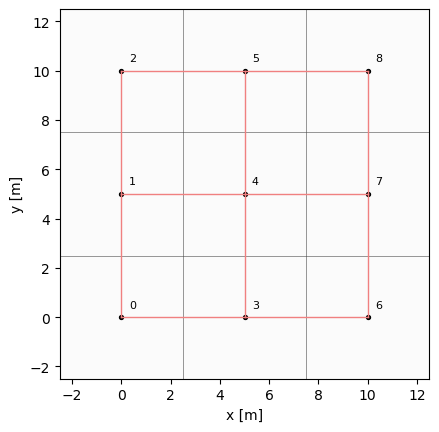

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [m]', ylabel='y [m]'>)

In [2]:
model.field.plot_field(show_ids=True, show_graph=True)

In [3]:
nsup = m_mesh_sup + 1
nground = n_mesh * m_mesh
nb = n_mesh * props_b.n_equations
ninf = m_mesh_inf
reference_borehole = 0

time = np.arange(dt, dt * (n_steps + 1), dt, dtype=np.float64,)

In [4]:
import matplotlib.pyplot as plt

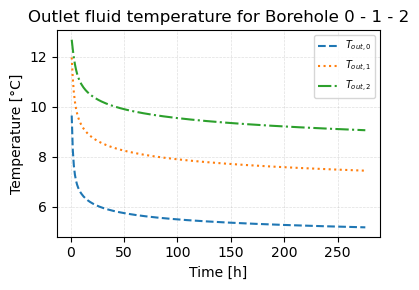

In [5]:
Tfout0 = T_history[1:, 0, nsup + nground + (props_b.n_equations - 1)]
Tfout1 = T_history[1:, 1, nsup + nground + (props_b.n_equations - 1)]
Tfout2 = T_history[1:, 2, nsup + nground + (props_b.n_equations - 1)]

fig, ax = plt.subplots(figsize = (4, 3)) #to create figure + one Axes


ax.plot(time / 3600, Tfout0, linestyle = "--", label = r"$T_{out,0}$")
ax.plot(time / 3600, Tfout1, linestyle = ":", label = r"$T_{out,1}$")
ax.plot(time / 3600, Tfout2, linestyle = "-.", label = r"$T_{out,2}$")

ax.legend(fontsize = 7)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Temperature [°C]")
ax.grid(True, which = 'major', linestyle = '--', linewidth = 0.5, alpha = 0.4)

ax.set_title("Outlet fluid temperature for Borehole 0 - 1 - 2")
plt.tight_layout()
plt.show()

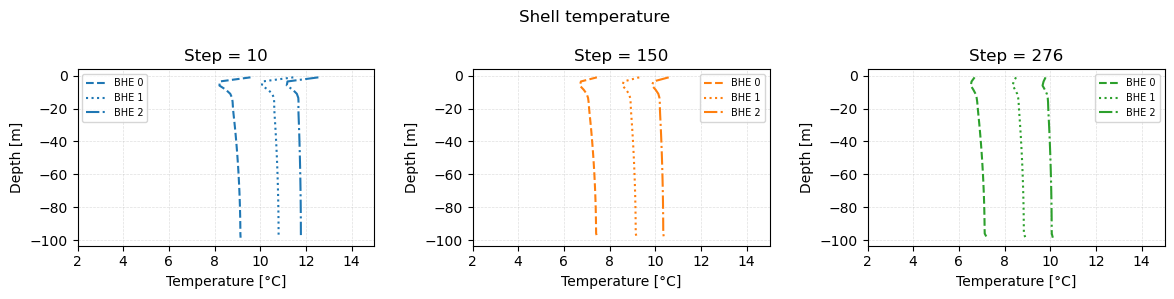

In [6]:
slice_depth = [nsup + nground + j*props_b.n_equations for j in range(m_mesh)]
depth = np.arange(- L_sup, - L_sup - model.ground[0].dz * (m_mesh), - model.ground[0].dz)
Bhe0 = 0
Bhe1 = 1
Bhe2 = 2

#Borehole 0
Tshell0_10 = T_history[11, Bhe0, slice_depth]
Tshell0_150 = T_history[151, Bhe0, slice_depth]
Tshell0_276 = T_history[276, Bhe0, slice_depth]
#Borehole 1
Tshell1_10 = T_history[11, Bhe1, slice_depth]
Tshell1_150 = T_history[151, Bhe1, slice_depth]
Tshell1_276 = T_history[276, Bhe1, slice_depth]
#Borehole 2
Tshell2_10 = T_history[11, Bhe2, slice_depth]
Tshell2_150 = T_history[151, Bhe2, slice_depth]
Tshell2_276 = T_history[276, Bhe2, slice_depth]

fig, axes = plt.subplots(1, 3, figsize = (12, 3))
ax1, ax2, ax3 = axes

ax1.plot(Tshell0_10, depth, color = "tab:blue", linestyle = "--", label = f"BHE {Bhe0}")
ax1.plot(Tshell1_10, depth, color = "tab:blue", linestyle = ":", label = f"BHE {Bhe1}")
ax1.plot(Tshell2_10, depth, color = "tab:blue", linestyle = "-.", label = f"BHE {Bhe2}")
ax1.set_title("Step = 10")

ax2.plot(Tshell0_150, depth, color = "tab:orange", linestyle = "--", label = f"BHE {Bhe0}")
ax2.plot(Tshell1_150, depth, color = "tab:orange", linestyle = ":", label = f"BHE {Bhe1}")
ax2.plot(Tshell2_150, depth, color = "tab:orange", linestyle = "-.", label = f"BHE {Bhe2}")
ax2.set_title("Step = 150")

ax3.plot(Tshell0_276, depth, color = "tab:green", linestyle = "--", label = f"BHE {Bhe0}")
ax3.plot(Tshell1_276, depth, color = "tab:green", linestyle = ":", label = f"BHE {Bhe1}")
ax3.plot(Tshell2_276, depth, color = "tab:green", linestyle = "-.", label = f"BHE {Bhe2}")
ax3.set_title("Step = 276")

for ax in axes:
    ax.set_xlabel("Temperature [°C]")
    ax.set_ylabel("Depth [m]")
    ax.set_xlim(2, 15)
    ax.legend(fontsize=7)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.4)
    ax.grid(True, which = 'major', linestyle = '--', linewidth = 0.5, alpha = 0.4)

fig.suptitle("Shell temperature")
plt.tight_layout()
plt.show()

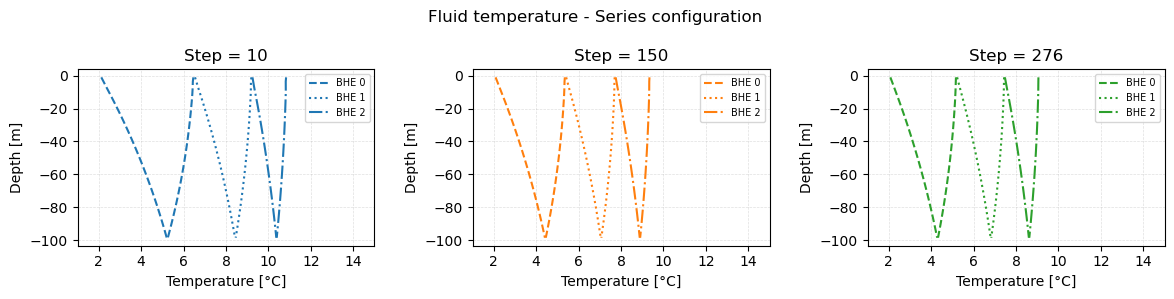

In [7]:
slice_down = [nsup + nground + (props_b.n_equations * j) + (props_b.n_equations - 2) for j in range(m_mesh)]
slice_up   = [nsup + nground + (props_b.n_equations * j) + (props_b.n_equations - 1) for j in range(m_mesh)]
depth = np.arange(-L_sup, -L_sup - model.ground[0].dz * m_mesh, -model.ground[0].dz)
Bhe0 = 0
Bhe1 = 1
Bhe2 = 2
 #Borehole 0
T_down0_10  = T_history[11,  Bhe0, slice_down]
T_down0_150 = T_history[151, Bhe0, slice_down]
T_down0_276 = T_history[276, Bhe0, slice_down]
T_up0_10    = T_history[11,  Bhe0, slice_up]
T_up0_150   = T_history[151, Bhe0, slice_up]
T_up0_276   = T_history[276, Bhe0, slice_up]

#Borehole 1
T_down1_10  = T_history[11,  Bhe1, slice_down]
T_down1_150 = T_history[151, Bhe1, slice_down]
T_down1_276 = T_history[276, Bhe1, slice_down]
T_up1_10    = T_history[11,  Bhe1, slice_up]
T_up1_150   = T_history[151, Bhe1, slice_up]
T_up1_276   = T_history[276, Bhe1, slice_up]

#Borehole 2
T_down2_10  = T_history[11,  Bhe2, slice_down]
T_down2_150 = T_history[151, Bhe2, slice_down]
T_down2_276 = T_history[276, Bhe2, slice_down]
T_up2_10    = T_history[11,  Bhe2, slice_up]
T_up2_150   = T_history[151, Bhe2, slice_up]
T_up2_276   = T_history[276, Bhe2, slice_up]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
ax1, ax2, ax3 = axes

ax1.plot(T_down0_10, depth, color="tab:blue",   linestyle="--", label=f"BHE {Bhe0}")
ax1.plot(T_up0_10,   depth, color="tab:blue",   linestyle="--")
ax1.plot(T_down1_10, depth, color="tab:blue", linestyle=":", label=f"BHE {Bhe1}")
ax1.plot(T_up1_10,   depth, color="tab:blue", linestyle=":")
ax1.plot(T_down2_10, depth, color="tab:blue",  linestyle="-.", label=f"BHE {Bhe2}")
ax1.plot(T_up2_10,   depth, color="tab:blue",  linestyle="-.")
ax1.set_title("Step = 10")

ax2.plot(T_down0_150, depth, color="tab:orange",   linestyle="--", label=f"BHE {Bhe0}")
ax2.plot(T_up0_150,   depth, color="tab:orange",   linestyle="--")
ax2.plot(T_down1_150, depth, color="tab:orange", linestyle=":", label=f"BHE {Bhe1}")
ax2.plot(T_up1_150,   depth, color="tab:orange", linestyle=":")
ax2.plot(T_down2_150, depth, color="tab:orange",  linestyle="-.", label=f"BHE {Bhe2}")
ax2.plot(T_up2_150,   depth, color="tab:orange",  linestyle="-.")
ax2.set_title("Step = 150")

ax3.plot(T_down0_276, depth, color="tab:green",   linestyle="--", label=f"BHE {Bhe0}")
ax3.plot(T_up0_276,   depth, color="tab:green",   linestyle="--")
ax3.plot(T_down1_276, depth, color="tab:green", linestyle=":", label=f"BHE {Bhe1}")
ax3.plot(T_up1_276,   depth, color="tab:green", linestyle=":")
ax3.plot(T_down2_276, depth, color="tab:green",  linestyle="-.", label=f"BHE {Bhe2}")
ax3.plot(T_up2_276,   depth, color="tab:green",  linestyle="-.")
ax3.set_title("Step = 276")

for ax in axes:
    ax.set_xlabel("Temperature [°C]")
    ax.set_ylabel("Depth [m]")
    ax.set_xlim(1, 15)
    ax.legend(fontsize=7)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.4)

fig.suptitle("Fluid temperature - Series configuration")
plt.tight_layout()
plt.show()

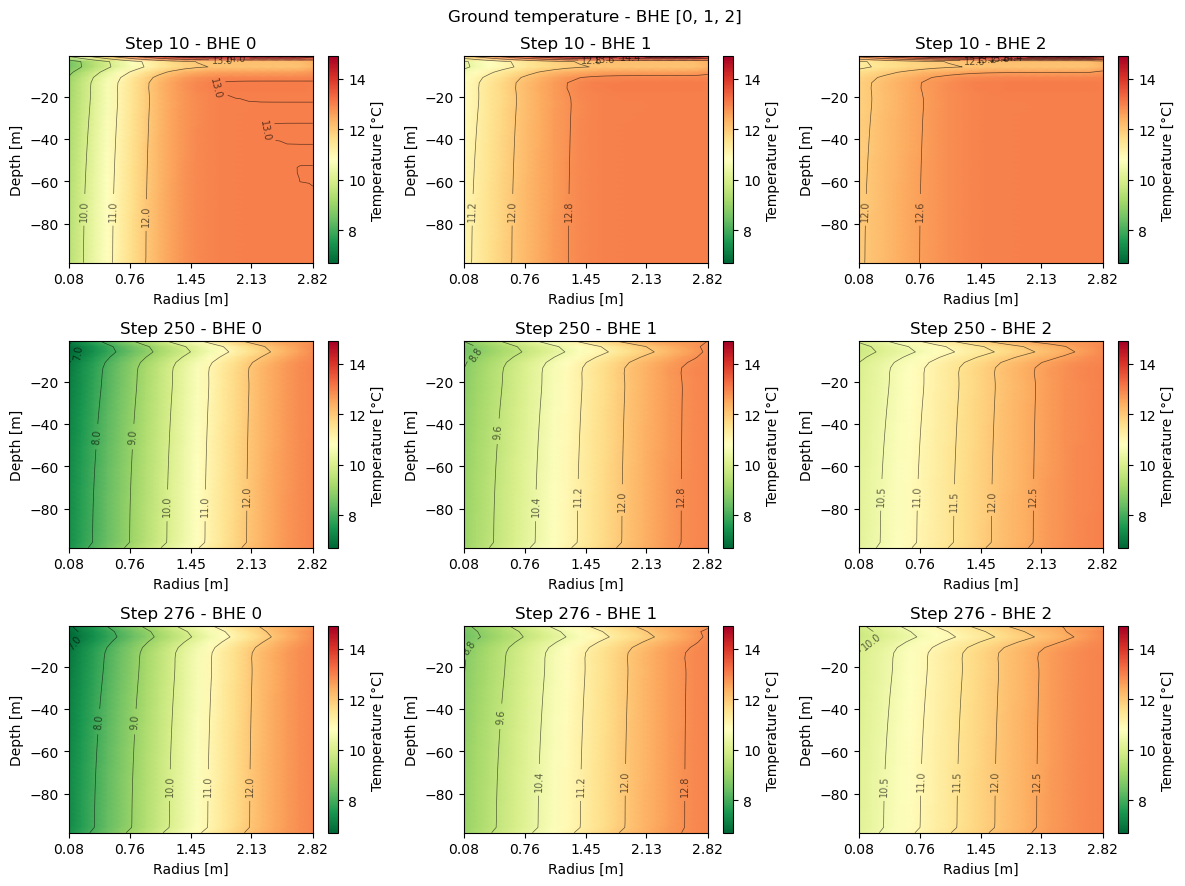

In [9]:
nsup = m_mesh_sup + 1
steps = [10, 500, 2160]
steps = [10, 1000, 8760]
steps = [10, 250, 276]
bhes = [0, 1, 2]
r0 = model.ground[0].r0
rn = model.ground[0].rn
dz = model.ground[0].dz

fig, axes = plt.subplots(3, 3, figsize=(12, 9))

T_all = T_history[np.ix_(steps, bhes)][:, :, nsup : nsup + nground ].reshape(len(steps), len(bhes), m_mesh, n_mesh)

vmin, vmax = T_all.min(), T_all.max()

x_ticks = np.round(np.linspace(r0, rn, 5), decimals = 2)

depth = np.arange(-L_sup, -L_sup - dz * m_mesh, -dz)
radius = np.linspace(D0/2, rn, n_mesh)
R, D = np.meshgrid(radius, depth)

for b in bhes:
    for i, t in enumerate(steps):
        ax = axes[i, b]

        pc = ax.pcolormesh(R, D, T_all[i, b], cmap='RdYlGn_r', shading='gouraud', vmin=vmin, vmax=vmax)
        contours = ax.contour(R, D, T_all[i, b], levels=6, colors='black', linewidths=0.5, alpha=0.6)
        ax.clabel(contours, inline=True, fontsize=7, fmt='%.1f', inline_spacing=5)
        ax.set_xlabel("Radius [m]")
        ax.set_ylabel("Depth [m]")
        fig.colorbar(pc, ax=ax, label="Temperature [°C]")
        ax.set_title(f"Step {t} - BHE {b}")
        ax.set_xlim((r0, rn))
        ax.set_xticks(x_ticks)

    fig.suptitle(f"Ground temperature - BHE {bhes}")
plt.tight_layout()
plt.show()

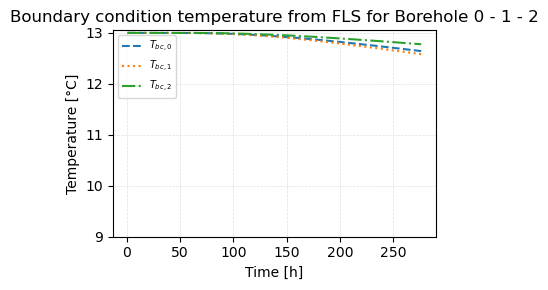

In [ ]:
bhes = [0, 1, 2]
T_bc_mean = np.mean(simulation.T_bc[:, bhes, :], axis = 2)

Tbc0 = T_bc_mean[:, 0]
Tbc1 = T_bc_mean[:, 1]
Tbc2 = T_bc_mean[:, 2]

fig, ax = plt.subplots(figsize = (4, 3))

ax.plot(time / 3600, Tbc0, linestyle = "--", label = r"$T_{bc,0}$")
ax.plot(time / 3600, Tbc1, linestyle = ":", label = r"$T_{bc,1}$")
ax.plot(time / 3600, Tbc2, linestyle = "-.", label = r"$T_{bc,2}$")

ax.legend(fontsize = 7)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Temperature [°C]")
ax.grid(True, which = 'major', linestyle = '--', linewidth = 0.5, alpha = 0.4)
ax.set_ylim(9, 13.05)

ax.set_title("Boundary condition temperature from FLS for Borehole 0 - 1 - 2")
plt.tight_layout()
plt.show()
